# Hierarchical Clustering — Complete Mathematical & Practical Guide

**Learning path:** Problem → Intuition → Mathematics → Distance → Linkage → From Scratch → Dendrogram → Scikit-learn → Evaluation → Comparison → Practical Application → Failure Cases

This notebook develops **Hierarchical Clustering** from its core idea and mathematical definitions to a transparent implementation and a practical `scikit-learn` workflow.

Unlike K-Means, hierarchical clustering does not require us to choose the final number of clusters before constructing the hierarchy.

## Learning Objectives

By completing this notebook, you will be able to:

- Explain what hierarchical clustering solves.
- Distinguish **agglomerative** and **divisive** hierarchical clustering.
- Understand how agglomerative clustering builds a hierarchy.
- Calculate common distance measures.
- Understand **single, complete, average, and Ward linkage**.
- Understand the mathematical meaning of linkage criteria.
- Implement a simple agglomerative algorithm from scratch.
- Visualize hierarchical clustering with a **dendrogram**.
- Read a dendrogram and choose a possible number of clusters.
- Use `sklearn.cluster.AgglomerativeClustering`.
- Compare different linkage strategies.
- Evaluate clustering with Silhouette Score and Davies-Bouldin Score.
- Understand the effect of feature scaling.
- Compare K-Means and Hierarchical Clustering.
- Recognize important failure cases and limitations.
- Apply hierarchical clustering to a small biological-style example.

In [1]:
# Import the core numerical and visualization libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make random examples reproducible.
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# 1. What Is Hierarchical Clustering?

**Hierarchical Clustering** is an unsupervised learning method that organizes observations into a hierarchy of nested groups.

Instead of producing only one flat partition, the algorithm builds a sequence of merges or splits.

The result can be represented as a **tree-like structure** called a **dendrogram**.

A major advantage is that the hierarchy can be inspected at different levels, allowing us to obtain different numbers of clusters from the same fitted hierarchy.

# 2. Intuition

Imagine that every observation starts as its own cluster.

For **agglomerative hierarchical clustering**:

1. Start with one cluster for every observation.
2. Find the two closest clusters.
3. Merge them.
4. Recalculate the distances between the new cluster and all remaining clusters.
5. Repeat until all observations belong to one cluster.

The algorithm therefore builds a hierarchy from many small clusters toward one large cluster.

In [2]:
# Create a tiny one-dimensional example so the merging idea is easy to inspect.
X_tiny = np.array([
    [1.0],
    [1.5],
    [5.0],
    [5.5],
    [10.0]
])

# Display the observations.
pd.DataFrame(X_tiny, columns=["feature"])

,feature
0,1.0
1,1.5
2,5.0
3,5.5
4,10.0


# 3. Agglomerative vs Divisive Clustering

There are two broad directions for hierarchical clustering.

### Agglomerative

Agglomerative clustering is **bottom-up**:

- Every observation starts as its own cluster.
- Similar clusters are repeatedly merged.
- The process ends with one cluster containing all observations.

### Divisive

Divisive clustering is **top-down**:

- All observations start in one cluster.
- A cluster is repeatedly split into smaller groups.
- The process continues until the desired hierarchy is obtained.

In practical machine-learning workflows, **agglomerative hierarchical clustering** is the approach most commonly encountered.

# 4. Why Do We Need a Distance?

To decide which observations or clusters should be merged, we need a definition of similarity.

For two observations $x_i$ and $x_j$, a general distance can be written as:

$$
d(x_i, x_j)
$$

A smaller distance means that the observations are considered more similar under that distance definition.

The choice of distance matters because changing the distance can change the resulting hierarchy.

## 4.1 Euclidean Distance

For two observations with $p$ features:

$$
d(x_i, x_j)
=
\sqrt{
\sum_{k=1}^{p}
(x_{ik} - x_{jk})^2
}
$$

Euclidean distance is especially natural for continuous numerical features when the feature scales are comparable.

In [3]:
# Calculate Euclidean distance between two observations.
def euclidean_distance(x, y):
    # Convert inputs to NumPy arrays so vectorized arithmetic works.
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Return the standard Euclidean distance.
    return np.sqrt(np.sum((x - y) ** 2))


# Test the function on two points.
point_a = np.array([1.0, 2.0])
point_b = np.array([4.0, 6.0])

euclidean_distance(point_a, point_b)

np.float64(5.0)

## 4.2 Manhattan Distance

Manhattan distance is defined as:

$$
d(x_i, x_j)
=
\sum_{k=1}^{p}
|x_{ik} - x_{jk}|
$$

It measures the total absolute coordinate difference.

Different distance measures can produce different notions of neighborhood and therefore different clustering structures.

In [4]:
# Calculate Manhattan distance between two observations.
def manhattan_distance(x, y):
    # Convert inputs to NumPy arrays.
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Sum the absolute differences across features.
    return np.sum(np.abs(x - y))


manhattan_distance(point_a, point_b)

np.float64(7.0)

# 5. Linkage: How Do We Measure Distance Between Clusters?

Once every observation is initially its own cluster, the algorithm must eventually compare **clusters**, not just individual observations.

This is where the **linkage criterion** becomes important.

Suppose cluster $A$ contains observations $a_i$ and cluster $B$ contains observations $b_j$.

Different linkage methods define the distance between $A$ and $B$ differently.

The four important methods in this notebook are:

- Single linkage
- Complete linkage
- Average linkage
- Ward linkage

## 5.1 Single Linkage

Single linkage uses the closest pair of observations across the two clusters:

$$
D_{	ext{single}}(A,B)
=
\min_{x \in A,\; y \in B}
d(x,y)
$$

It can connect clusters through chains of nearby observations.

**Strength:** can discover elongated structures.

**Weakness:** sensitive to chaining and noise.

## 5.2 Complete Linkage

Complete linkage uses the farthest pair:

$$
D_{	ext{complete}}(A,B)
=
\max_{x \in A,\; y \in B}
d(x,y)
$$

It tends to favor compact clusters because even the most distant points between two clusters must remain relatively close.

## 5.3 Average Linkage

**Average linkage** defines the distance between two clusters as the average of all pairwise distances between their observations.

$$
D_{\text{average}}(A,B)
=
\frac{1}{|A||B|}
\sum_{x \in A}
\sum_{y \in B}
d(x,y)
$$

where:

- \(A\) and \(B\) are two clusters.
- \(|A|\) and \(|B|\) are the number of observations in each cluster.
- \(d(x,y)\) is the distance between observations \(x\) and \(y\).

Unlike **single linkage**, which considers only the closest pair of observations, and **complete linkage**, which considers only the farthest pair, average linkage considers **all pairwise distances**.

Therefore, it provides a balance between single and complete linkage and is generally less sensitive to extreme pairwise distances than complete linkage.

## 5.4 Ward Linkage

Ward linkage chooses a merge that produces the smallest increase in within-cluster squared error.

For a cluster $C$, its within-cluster sum of squares can be written as:

$$
W(C)
=
\sum_{x \in C}
\|x-\mu_C\|^2
$$

where $\mu_C$ is the centroid of cluster $C$.

For two candidate clusters $A$ and $B$, Ward's method prefers the merge that causes the smallest increase in this quantity.

**Important:** Ward linkage is associated with Euclidean geometry and is especially useful when compact, variance-minimizing clusters are appropriate.

# 6. The Agglomerative Algorithm

The basic algorithm can be summarized as:

1. Create $n$ singleton clusters.
2. Compute distances between clusters.
3. Find the pair with the smallest linkage distance.
4. Merge the pair.
5. Record the merge and its distance.
6. Repeat until one cluster remains.

At each merge, the number of clusters decreases by one.

Starting with $n$ observations therefore produces $n-1$ merge operations.

# 7. A Small Example by Hand

Consider four one-dimensional observations:

$$
X = \{1,\;2,\;8,\;9\}
$$

The closest pair is:

$$
d(1,2)=1
$$

and:

$$
d(8,9)=1
$$

Therefore, the hierarchy begins by merging $(1,2)$ and $(8,9)$.

The next merge combines the two resulting clusters.

This example illustrates an important point: hierarchical clustering does not immediately decide that the final answer must contain two clusters. It constructs the complete hierarchy first.

In [5]:
# Create the small one-dimensional example.
X_hand = np.array([[1.0], [2.0], [8.0], [9.0]])

# Compute the pairwise Euclidean distance matrix manually.
distance_matrix = np.zeros((len(X_hand), len(X_hand)))

for i in range(len(X_hand)):
    for j in range(len(X_hand)):
        # Store the distance between observations i and j.
        distance_matrix[i, j] = euclidean_distance(X_hand[i], X_hand[j])

pd.DataFrame(
    distance_matrix,
    index=["1", "2", "8", "9"],
    columns=["1", "2", "8", "9"]
)

,1,2,8,9
1,0.0,1.0,7.0,8.0
2,1.0,0.0,6.0,7.0
8,7.0,6.0,0.0,1.0
9,8.0,7.0,1.0,0.0


# 8. A Simple Agglomerative Implementation From Scratch

The following implementation is intentionally educational.

It uses:

- Euclidean distance
- Single linkage
- A simple list of clusters
- Explicit search for the closest pair

This is **not intended to replace optimized scientific libraries**. Its purpose is to make the algorithm's mechanics visible.

In [6]:
# A simple educational implementation of agglomerative clustering.
def agglomerative_single_linkage(X):
    # Convert the input data to a floating-point NumPy array.
    X = np.asarray(X, dtype=float)

    # Start with one cluster for every observation.
    clusters = [[i] for i in range(len(X))]

    # Store every merge as:
    # (left_cluster, right_cluster, merge_distance, new_cluster_size)
    history = []

    while len(clusters) > 1:
        # Track the best pair found so far.
        best_distance = np.inf
        best_pair = None

        # Compare every pair of current clusters.
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                # Calculate single-linkage distance:
                # the minimum distance between any two observations.
                distances = [
                    euclidean_distance(X[a], X[b])
                    for a in clusters[i]
                    for b in clusters[j]
                ]
                cluster_distance = min(distances)

                # Update the best pair when a smaller distance is found.
                if cluster_distance < best_distance:
                    best_distance = cluster_distance
                    best_pair = (i, j)

        # Retrieve the selected cluster indices.
        i, j = best_pair

        # Save copies before removing the old clusters.
        left_cluster = clusters[i].copy()
        right_cluster = clusters[j].copy()

        # Create the merged cluster.
        merged_cluster = left_cluster + right_cluster

        # Record the merge information.
        history.append(
            (
                left_cluster,
                right_cluster,
                best_distance,
                len(merged_cluster)
            )
        )

        # Remove the old clusters.
        # Remove the larger index first so the smaller index remains valid.
        for index in sorted([i, j], reverse=True):
            clusters.pop(index)

        # Add the newly merged cluster.
        clusters.append(merged_cluster)

    return history


# Run the educational implementation.
single_history = agglomerative_single_linkage(X_hand)

# Display the merge history.
single_history

[([0], [1], np.float64(1.0), 2),
 ([2], [3], np.float64(1.0), 2),
 ([0, 1], [2, 3], np.float64(6.0), 4)]

# 9. Visualizing the Data Before Clustering

A simple two-dimensional dataset is useful because we can see the groups directly.

We will generate three groups with different centers and then investigate how hierarchical clustering reconstructs their structure.

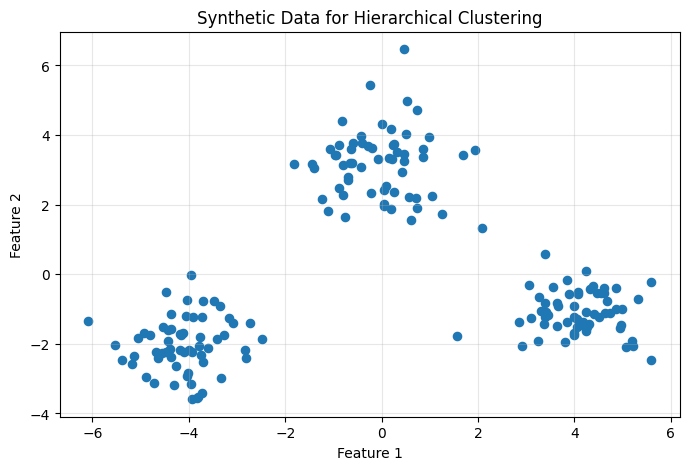

In [7]:
from sklearn.datasets import make_blobs

# Generate a synthetic dataset with three natural groups.
X_blobs, y_true = make_blobs(
    n_samples=180,
    centers=[(-4, -2), (0, 3), (4, -1)],
    cluster_std=[0.8, 0.9, 0.75],
    random_state=RANDOM_STATE
)

# Plot the observations without using the true labels for clustering.
plt.figure(figsize=(8, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=35)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Data for Hierarchical Clustering")
plt.grid(alpha=0.3)
plt.show()

# 10. The Dendrogram

A **dendrogram** is the standard visualization of hierarchical clustering.

It shows:

- which observations or clusters were merged,
- the order of merges,
- the distance at which each merge occurred.

The vertical position of a merge represents the dissimilarity or linkage distance at which the merge happened.

A large vertical jump can indicate a meaningful separation between groups.

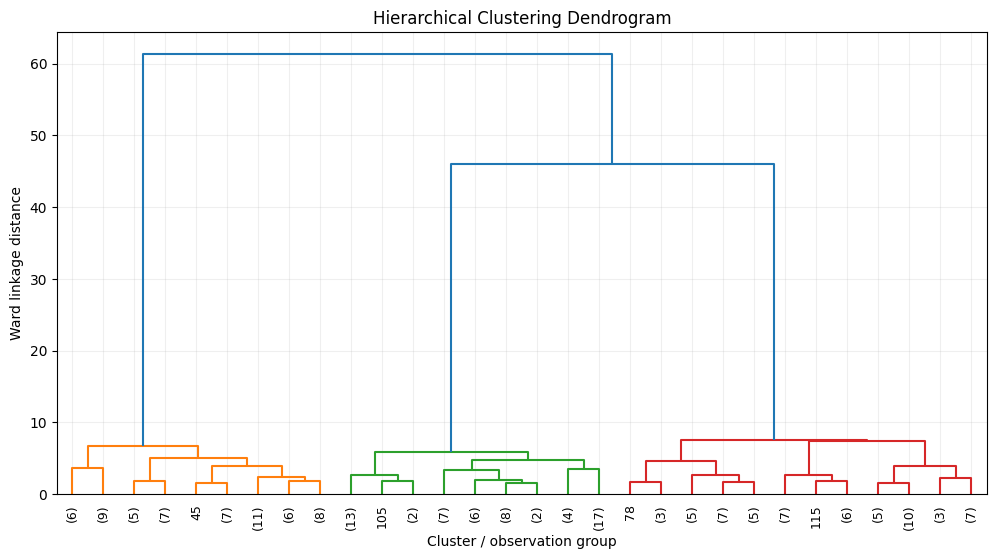

In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Compute the hierarchical linkage matrix using Ward's method.
Z = linkage(X_blobs, method="ward")

# Plot the dendrogram.
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9
)
plt.xlabel("Cluster / observation group")
plt.ylabel("Ward linkage distance")
plt.title("Hierarchical Clustering Dendrogram")
plt.grid(alpha=0.2)
plt.show()

# 11. How to Read a Dendrogram

A dendrogram can be interpreted from bottom to top:

- Leaves represent individual observations or condensed groups.
- Horizontal merges indicate that two groups were joined.
- The vertical height of a merge represents the linkage distance.
- A horizontal cut through the dendrogram creates a flat clustering.

For example, if a horizontal line intersects the dendrogram in three branches, the resulting partition contains approximately three clusters.

There is no universal rule that says the visually largest gap is always the correct answer. Domain knowledge and quantitative evaluation should also be considered.

# 12. Cutting the Dendrogram

Suppose the dendrogram suggests that a large jump occurs after several groups have already formed.

A horizontal cut can be placed before that jump.

Conceptually:

$$
	ext{Dendrogram}
\xrightarrow{	ext{horizontal cut}}
	ext{flat cluster labels}
$$

This is one of the major differences from K-Means: hierarchical clustering can build the hierarchy first and allow us to choose a level afterward.

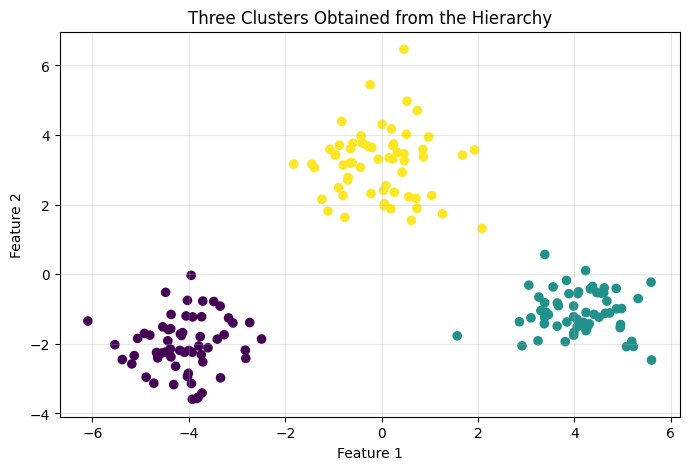

In [9]:
from scipy.cluster.hierarchy import fcluster

# Cut the Ward hierarchy to obtain three clusters.
labels_dendrogram = fcluster(
    Z,
    t=3,
    criterion="maxclust"
)

# Plot the resulting flat clustering.
plt.figure(figsize=(8, 5))
plt.scatter(
    X_blobs[:, 0],
    X_blobs[:, 1],
    c=labels_dendrogram,
    s=35
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Three Clusters Obtained from the Hierarchy")
plt.grid(alpha=0.3)
plt.show()

# 13. Linkage Methods in SciPy

The main linkage options we will compare are:

- `single`
- `complete`
- `average`
- `ward`

The same dataset can produce noticeably different hierarchies depending on the linkage strategy.

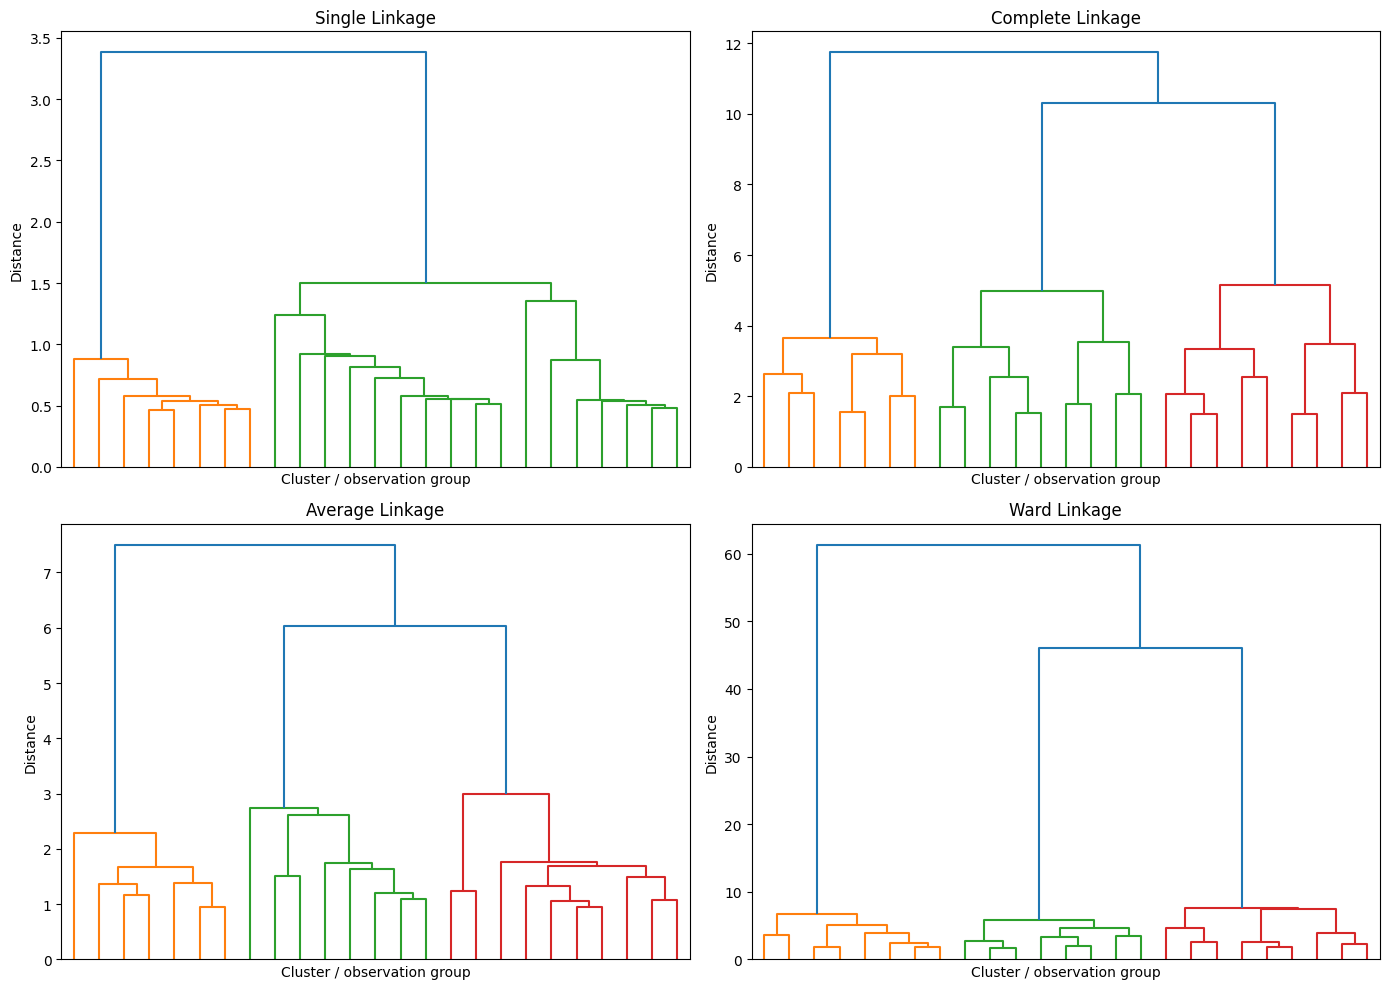

In [10]:
# Compare several linkage methods visually.
linkage_methods = ["single", "complete", "average", "ward"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, method in zip(axes.ravel(), linkage_methods):
    # Compute the linkage matrix for the current method.
    Z_method = linkage(X_blobs, method=method)

    # Draw a condensed dendrogram.
    dendrogram(
        Z_method,
        truncate_mode="lastp",
        p=25,
        ax=ax,
        no_labels=True
    )

    # Label the subplot.
    ax.set_title(f"{method.title()} Linkage")
    ax.set_xlabel("Cluster / observation group")
    ax.set_ylabel("Distance")

plt.tight_layout()
plt.show()

# 14. Scikit-learn: AgglomerativeClustering

`sklearn.cluster.AgglomerativeClustering` provides an optimized practical interface.

The main parameters include:

- `n_clusters`: number of final clusters.
- `metric`: distance metric used for supported linkage strategies.
- `linkage`: linkage strategy.
- `compute_distances`: optionally retain distances useful for inspection.

Unlike the low-level dendrogram workflow, this estimator directly returns a flat set of cluster labels.

In [11]:
from sklearn.cluster import AgglomerativeClustering

# Fit an agglomerative clustering model using Ward linkage.
hierarchical_model = AgglomerativeClustering(
    n_clusters=3,
    metric="euclidean",
    linkage="ward"
)

# Learn the hierarchy and return a label for each observation.
hierarchical_labels = hierarchical_model.fit_predict(X_blobs)

# Display the first few labels.
hierarchical_labels[:20]

array([2, 0, 0, 2, 0, 2, 1, 0, 2, 2, 0, 1, 1, 0, 1, 2, 1, 2, 1, 1])

## Visualize the Scikit-learn Result

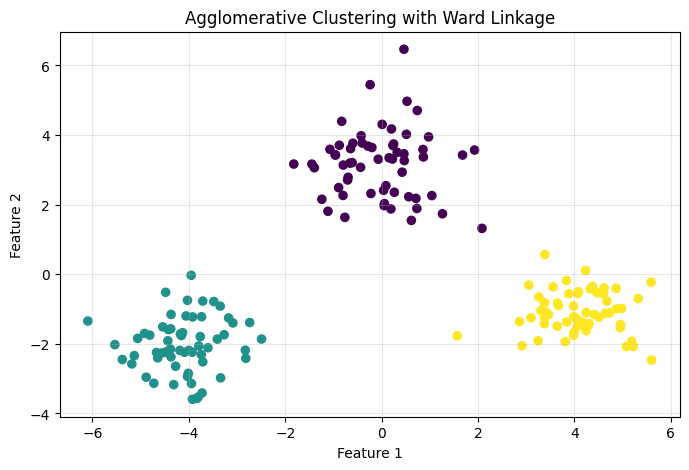

In [12]:
# Visualize the clusters returned by AgglomerativeClustering.
plt.figure(figsize=(8, 5))
plt.scatter(
    X_blobs[:, 0],
    X_blobs[:, 1],
    c=hierarchical_labels,
    s=35
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering with Ward Linkage")
plt.grid(alpha=0.3)
plt.show()

# 15. Comparing Linkage Methods in Scikit-learn

For a fair comparison, we can keep the number of clusters fixed and change only the linkage strategy.

For Ward linkage, Euclidean distance is required.

For single, complete, and average linkage, other supported distance metrics may also be used depending on the estimator version and configuration.

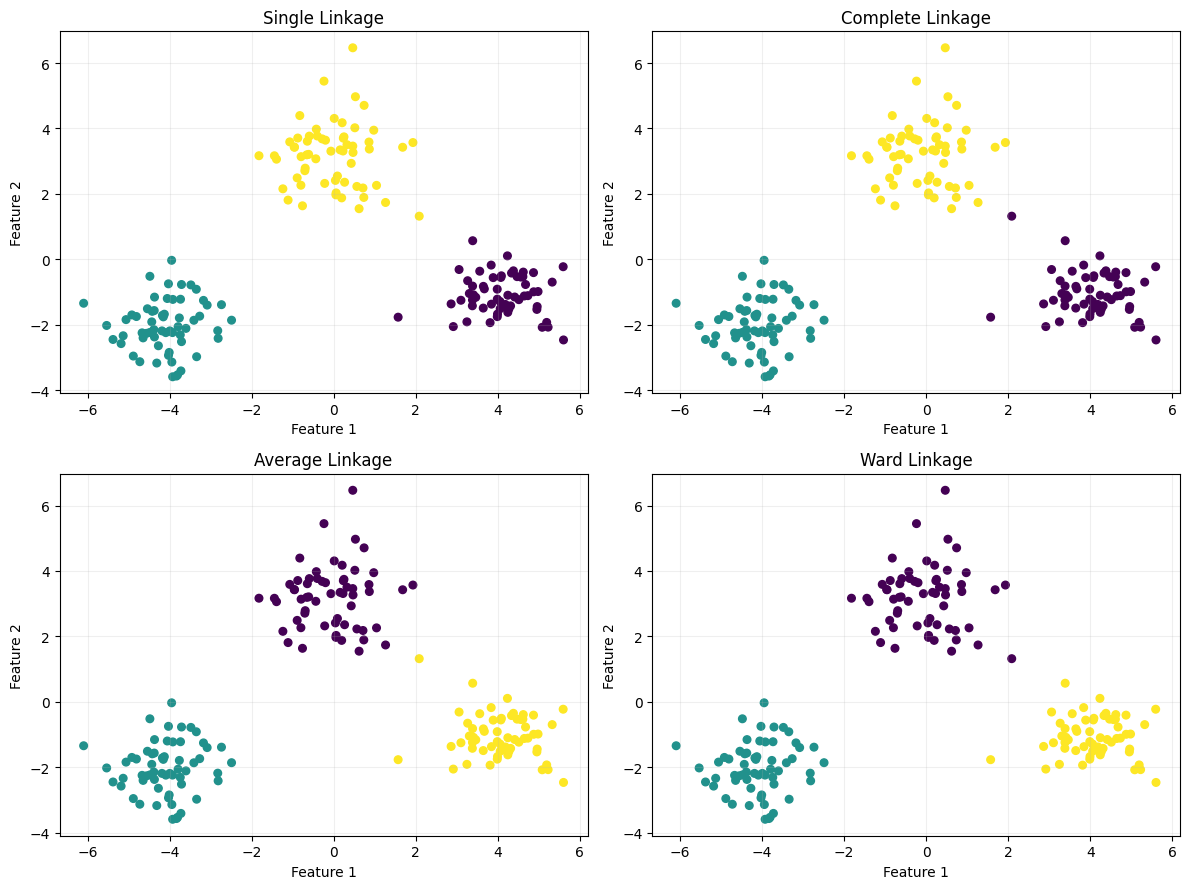

In [13]:
# Compare several linkage methods on the same dataset.
results = {}

for method in ["single", "complete", "average", "ward"]:
    # Build the model with the current linkage strategy.
    model = AgglomerativeClustering(
        n_clusters=3,
        metric="euclidean",
        linkage=method
    )

    # Fit the model and save the cluster labels.
    results[method] = model.fit_predict(X_blobs)

# Plot all four results.
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, method in zip(axes.ravel(), results):
    ax.scatter(
        X_blobs[:, 0],
        X_blobs[:, 1],
        c=results[method],
        s=30
    )
    ax.set_title(f"{method.title()} Linkage")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 16. Choosing the Number of Clusters

Hierarchical clustering gives us a hierarchy, but many practical tasks still require a flat partition.

Several strategies can help:

1. Inspect a dendrogram.
2. Use domain knowledge.
3. Compare internal clustering metrics.
4. Test the stability of the resulting groups.
5. Consider whether the clusters are scientifically interpretable.

The dendrogram is therefore a **decision-support tool**, not an automatic guarantee of the correct number of clusters.

# 17. Silhouette Score

For observation $i$, let:

- $a(i)$ be the average distance from $i$ to points in its own cluster.
- $b(i)$ be the smallest average distance from $i$ to points in another cluster.

The silhouette coefficient is:

$$
s(i)
=
rac{b(i)-a(i)}
{\max(a(i),b(i))}
$$

The average silhouette score summarizes the clustering.

Higher values generally indicate better separation and cohesion, but the score should not be interpreted without considering the geometry and scientific meaning of the clusters.

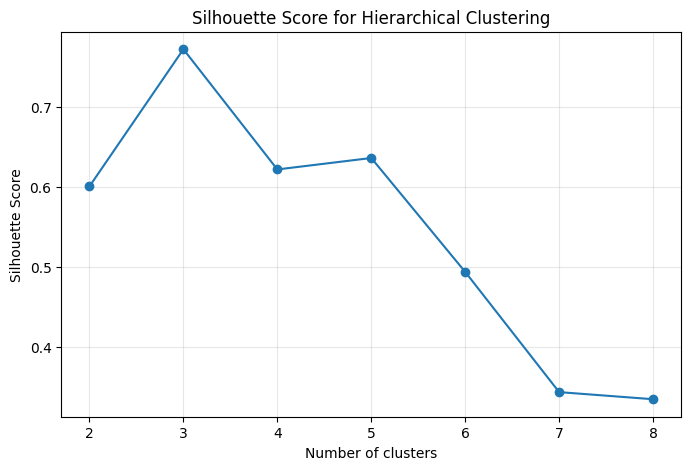

In [15]:
from sklearn.metrics import silhouette_score

# Evaluate candidate numbers of clusters.
candidate_k = range(2, 9)
silhouette_scores = []

for k in candidate_k:
    # Fit hierarchical clustering with the current number of clusters.
    model = AgglomerativeClustering(
        n_clusters=k,
        metric="euclidean",
        linkage="ward"
    )
    labels = model.fit_predict(X_blobs)

    # Calculate the average silhouette score.
    silhouette_scores.append(
        silhouette_score(X_blobs, labels)
    )

# Plot the scores.
plt.figure(figsize=(8, 5))
plt.plot(candidate_k, silhouette_scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Hierarchical Clustering")
plt.xticks(list(candidate_k))
plt.grid(alpha=0.3)
plt.show()

# 18. Davies-Bouldin Score

The Davies-Bouldin index compares within-cluster scatter with between-cluster separation.

A lower score is generally better.

It is useful as a complementary metric because no single clustering metric completely describes cluster quality.

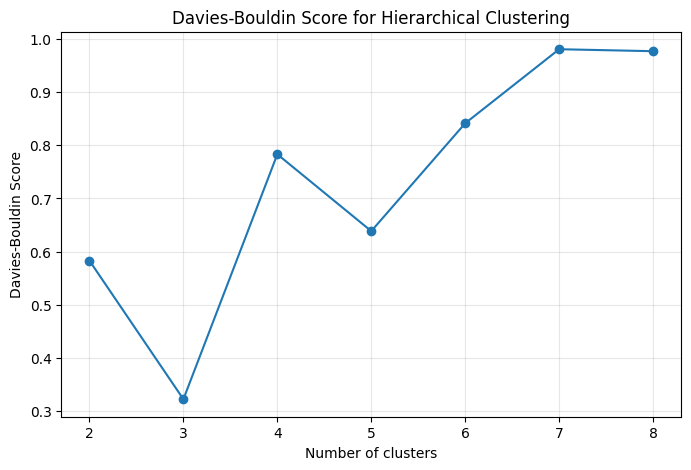

In [16]:
from sklearn.metrics import davies_bouldin_score

# Evaluate the same candidate cluster counts using Davies-Bouldin Score.
db_scores = []

for k in candidate_k:
    # Fit the hierarchical model.
    model = AgglomerativeClustering(
        n_clusters=k,
        metric="euclidean",
        linkage="ward"
    )
    labels = model.fit_predict(X_blobs)

    # Calculate the Davies-Bouldin score.
    db_scores.append(
        davies_bouldin_score(X_blobs, labels)
    )

# Plot the scores.
plt.figure(figsize=(8, 5))
plt.plot(candidate_k, db_scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Davies-Bouldin Score")
plt.title("Davies-Bouldin Score for Hierarchical Clustering")
plt.xticks(list(candidate_k))
plt.grid(alpha=0.3)
plt.show()

# 19. Feature Scaling

Distance-based algorithms are sensitive to the scale of input features.

Suppose one feature ranges from \(0\) to \(1\), while another ranges from \(0\) to \(100{,}000\).

The second feature can dominate the distance calculation, even if it is not biologically or scientifically more important.

A common approach is **standardization**, which transforms each feature approximately as:

$$
z
=
\frac{x-\mu}{\sigma}
$$

where:

- \(x\) is the original feature value.
- \(\mu\) is the feature mean.
- \(\sigma\) is the feature standard deviation.
- \(z\) is the standardized value.

After standardization, the feature has approximately:

$$
\mu = 0
\qquad\text{and}\qquad
\sigma = 1
$$

Feature scaling is especially important for algorithms that rely on distances or geometric relationships, such as:

- K-Means
- K-Nearest Neighbors (KNN)
- Support Vector Machines (SVM)
- Hierarchical Clustering

Without appropriate scaling, features with larger numerical ranges may disproportionately influence the model.

In [17]:
from sklearn.preprocessing import StandardScaler

# Create an intentionally differently scaled version of the data.
X_scaled = StandardScaler().fit_transform(X_blobs)

# Compare the original and standardized feature ranges.
scale_comparison = pd.DataFrame({
    "original_mean": X_blobs.mean(axis=0),
    "original_std": X_blobs.std(axis=0),
    "scaled_mean": X_scaled.mean(axis=0),
    "scaled_std": X_scaled.std(axis=0)
})

scale_comparison

,original_mean,original_std,scaled_mean,scaled_std
0,-0.010498,3.433067,1.850372e-17,1.0
1,0.017776,2.397798,3.268990e-17,1.0


# 20. Hierarchical Clustering with Scaled Data

In real projects, scaling should be treated as part of the preprocessing design rather than as an automatic step.

Ask:

- Are the features measured in comparable units?
- Is magnitude itself meaningful?
- Are there extreme outliers?
- Would normalization or another transformation be scientifically justified?

The correct preprocessing depends on the problem.

In [18]:
# Fit Ward hierarchical clustering after standardization.
scaled_model = AgglomerativeClustering(
    n_clusters=3,
    metric="euclidean",
    linkage="ward"
)

scaled_labels = scaled_model.fit_predict(X_scaled)

# Evaluate the scaled clustering.
scaled_silhouette = silhouette_score(X_scaled, scaled_labels)

print(f"Silhouette Score after scaling: {scaled_silhouette:.4f}")

Silhouette Score after scaling: 0.7733


# 21. A More Realistic Feature Table

Hierarchical clustering is often applied to a table in which:

- rows represent samples, patients, cells, or experiments;
- columns represent measured features.

For example:

| Sample | Gene A | Gene B | Gene C |
|---|---:|---:|---:|
| S1 | 8.2 | 2.1 | 7.5 |
| S2 | 8.8 | 2.4 | 7.9 |
| S3 | 1.2 | 8.7 | 2.0 |
| S4 | 1.5 | 9.1 | 2.3 |

The algorithm uses the numerical feature vectors to determine similarity between samples.

# 22. Practical Bioinformatics-Style Example

Hierarchical clustering is widely useful for exploratory analysis of biological data.

A common conceptual workflow is:

$$
	ext{Biological measurements}
\rightarrow
	ext{Preprocessing}
\rightarrow
	ext{Distance}
\rightarrow
	ext{Hierarchical clustering}
\rightarrow
	ext{Dendrogram}
\rightarrow
	ext{Biological interpretation}
$$

Examples include:

- clustering samples using gene-expression profiles,
- grouping genes by expression patterns,
- exploring similarity between molecular profiles,
- clustering cell populations after dimensionality reduction or feature engineering.

The biological interpretation should come **after** checking preprocessing, distance choice, and cluster stability.

In [19]:
# Create a small synthetic gene-expression-style dataset.
gene_expression = pd.DataFrame(
    {
        "Gene_A": [8.2, 8.8, 8.5, 1.2, 1.5, 1.1, 5.0, 5.2, 4.8],
        "Gene_B": [2.1, 2.4, 2.0, 8.7, 9.1, 8.8, 5.1, 4.9, 5.3],
        "Gene_C": [7.5, 7.9, 7.2, 2.0, 2.3, 1.8, 5.2, 5.0, 4.7]
    },
    index=[
        "Sample_1", "Sample_2", "Sample_3",
        "Sample_4", "Sample_5", "Sample_6",
        "Sample_7", "Sample_8", "Sample_9"
    ]
)

gene_expression

,Gene_A,Gene_B,Gene_C
Sample_1,8.2,2.1,7.5
Sample_2,8.8,2.4,7.9
Sample_3,8.5,2.0,7.2
Sample_4,1.2,8.7,2.0
Sample_5,1.5,9.1,2.3
Sample_6,1.1,8.8,1.8
Sample_7,5.0,5.1,5.2
Sample_8,5.2,4.9,5.0
Sample_9,4.8,5.3,4.7


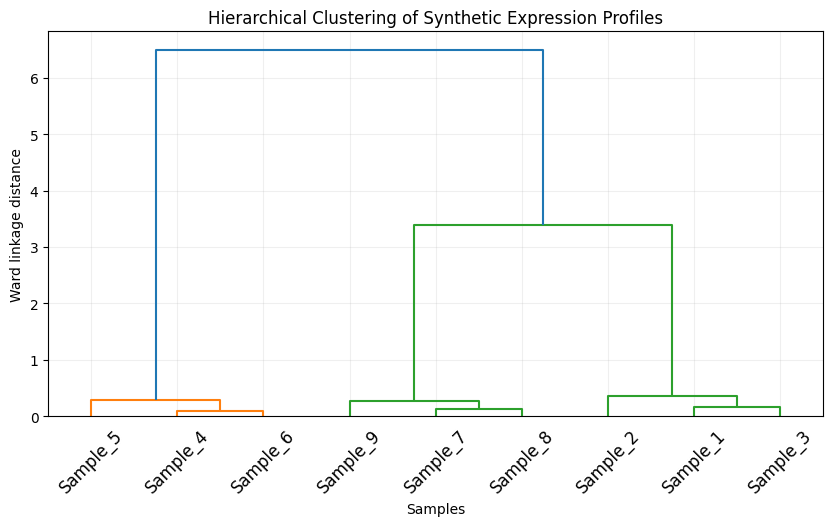

In [20]:
# Standardize the expression features before distance-based clustering.
expression_scaled = StandardScaler().fit_transform(gene_expression)

# Build the hierarchy using Ward linkage.
expression_Z = linkage(
    expression_scaled,
    method="ward"
)

# Display the dendrogram with sample names.
plt.figure(figsize=(10, 5))
dendrogram(
    expression_Z,
    labels=gene_expression.index.tolist(),
    leaf_rotation=45
)
plt.xlabel("Samples")
plt.ylabel("Ward linkage distance")
plt.title("Hierarchical Clustering of Synthetic Expression Profiles")
plt.grid(alpha=0.2)
plt.show()

# 23. Heatmap-Style View of Clustered Samples

For biological data, a dendrogram is often interpreted together with a feature matrix.

The key idea is to ask whether samples that are close in the hierarchy also show coherent feature patterns.

A full biological heatmap usually requires additional decisions about:

- normalization,
- transformation,
- feature selection,
- row/column scaling,
- distance,
- linkage.

Therefore, clustering should not be separated from preprocessing decisions.

In [21]:
# Obtain three sample groups from the expression hierarchy.
expression_labels = fcluster(
    expression_Z,
    t=3,
    criterion="maxclust"
)

# Add the resulting labels to the sample table.
expression_with_clusters = gene_expression.copy()
expression_with_clusters["cluster"] = expression_labels

expression_with_clusters

,Gene_A,Gene_B,Gene_C,cluster
Sample_1,8.2,2.1,7.5,3
Sample_2,8.8,2.4,7.9,3
Sample_3,8.5,2.0,7.2,3
Sample_4,1.2,8.7,2.0,1
Sample_5,1.5,9.1,2.3,1
Sample_6,1.1,8.8,1.8,1
Sample_7,5.0,5.1,5.2,2
Sample_8,5.2,4.9,5.0,2
Sample_9,4.8,5.3,4.7,2


# 24. K-Means vs Hierarchical Clustering

| Property | K-Means | Hierarchical |
|---|---|---|
| Must choose K before fitting | Yes | Not necessarily |
| Produces a hierarchy | No | Yes |
| Main representation | Centroids | Dendrogram |
| Typical objective | Within-cluster squared distance | Depends on linkage |
| Handles nested structure | Limited | Naturally represented |
| Large datasets | Usually more scalable | Can be more expensive |
| Sensitive to initialization | Yes | No random centroid initialization |
| Sensitive to distance/scale | Yes | Yes |
| Easy cluster visualization | Moderate | Excellent with dendrogram |

Neither algorithm is universally better.

The correct choice depends on dataset size, geometry, interpretability requirements, and scientific context.

# 25. Important Failure Cases

Hierarchical clustering can fail or become misleading when:

### 1. Features have incompatible scales

One feature can dominate the distance.

### 2. Strong outliers are present

A few observations can strongly influence merges.

### 3. The distance metric is inappropriate

A mathematically valid distance is not automatically a scientifically meaningful similarity measure.

### 4. Chaining occurs

Single linkage can connect groups through a sequence of intermediate points.

### 5. The hierarchy is over-interpreted

A dendrogram always exists, but not every branch represents a meaningful biological or scientific group.

### 6. Dataset size is too large

Naive hierarchical methods can require substantial computational and memory resources.

# 26. Computational Considerations

A major practical difference from K-Means is scalability.

K-Means repeatedly assigns observations to centroids and updates those centroids.

Hierarchical clustering must progressively maintain relationships between clusters.

The exact computational cost depends on the implementation, distance metric, linkage method, and dataset size.

For very large datasets, alternatives such as:

- K-Means,
- MiniBatchKMeans,
- approximate nearest-neighbor methods,
- dimensionality reduction followed by clustering,

may be more practical depending on the task.

# 27. Reproducibility

Hierarchical clustering itself does not use random centroid initialization in the way K-Means does.

However, the complete analysis can still become non-reproducible if randomness appears in:

- sampling,
- preprocessing,
- dimensionality reduction,
- train/test-like exploratory splits,
- synthetic data generation.

Always record:

- preprocessing steps,
- distance metric,
- linkage method,
- number of clusters,
- software versions when necessary,
- and the exact dataset used.

In [22]:
# Record the key configuration used in this notebook.
configuration = {
    "algorithm": "Agglomerative Hierarchical Clustering",
    "linkage": "ward",
    "metric": "euclidean",
    "n_clusters": 3,
    "random_state_for_data_generation": RANDOM_STATE
}

configuration

{'algorithm': 'Agglomerative Hierarchical Clustering',
 'linkage': 'ward',
 'metric': 'euclidean',
 'n_clusters': 3,
 'random_state_for_data_generation': 42}

# 28. Mini Project

## Sample Clustering Project

Build a small clustering analysis using a numerical dataset.

### Requirements

1. Load or generate a numerical dataset.
2. Inspect missing values.
3. Inspect feature scales.
4. Decide whether scaling is appropriate.
5. Compare at least three linkage methods.
6. Draw a dendrogram.
7. Test several numbers of clusters.
8. Calculate Silhouette Score.
9. Calculate Davies-Bouldin Score.
10. Visualize the final clusters.
11. Explain why you selected the final clustering.
12. Discuss limitations and possible biological/scientific interpretation.

### Suggested output

Your final notebook should contain:

- preprocessing,
- dendrogram,
- metric comparison,
- final clustering visualization,
- interpretation,
- limitations.

# 29. Exercises

### Exercise 1 — Distance

Implement Manhattan and Euclidean distance functions and compare them on several pairs of points.

### Exercise 2 — Linkage

For two small clusters, manually calculate:

- single linkage,
- complete linkage,
- average linkage.

### Exercise 3 — Dendrogram

Generate a dataset with four groups and investigate how the dendrogram changes with different linkage methods.

### Exercise 4 — Scaling

Multiply one feature by 100 and compare clustering before and after standardization.

### Exercise 5 — K-Means Comparison

Run K-Means and Hierarchical Clustering on the same dataset and compare:

- cluster geometry,
- Silhouette Score,
- computational behavior,
- interpretability.

### Exercise 6 — Bioinformatics

Create a small synthetic gene-expression matrix and cluster samples. Explain whether the resulting groups are biologically plausible.

# 30. Mastery Checklist

Before moving to the next unsupervised-learning algorithm, make sure you can answer:

- What is hierarchical clustering?
- What is the difference between agglomerative and divisive clustering?
- Why do we need a distance measure?
- What is linkage?
- How does single linkage work?
- How does complete linkage work?
- How does average linkage work?
- What is special about Ward linkage?
- What does a dendrogram represent?
- How can a dendrogram be converted into flat clusters?
- Why does feature scaling matter?
- How can Silhouette Score help?
- What does a low Davies-Bouldin Score indicate?
- When can single linkage suffer from chaining?
- When might K-Means be preferable?
- Why should clustering results be interpreted together with domain knowledge?

# 31. Function Cheat Sheet

### Core distance functions

- `euclidean_distance(x, y)` — educational Euclidean distance.
- `manhattan_distance(x, y)` — educational Manhattan distance.

### SciPy hierarchical clustering

- `scipy.cluster.hierarchy.linkage()` — build the hierarchical linkage matrix.
- `scipy.cluster.hierarchy.dendrogram()` — visualize the hierarchy.
- `scipy.cluster.hierarchy.fcluster()` — extract flat cluster labels.

### Scikit-learn

- `AgglomerativeClustering()` — perform agglomerative clustering.
- `.fit()` — fit the clustering model.
- `.fit_predict()` — fit and return cluster labels.

### Evaluation

- `silhouette_score()` — evaluate cohesion and separation.
- `davies_bouldin_score()` — evaluate cluster compactness/separation.

### Preprocessing

- `StandardScaler()` — standardize numerical features.

### Practical reminder

For a complete analysis, think in this order:

$$
	ext{Data}
\rightarrow
	ext{Preprocessing}
\rightarrow
	ext{Distance}
\rightarrow
	ext{Linkage}
\rightarrow
	ext{Dendrogram}
\rightarrow
	ext{Cluster selection}
\rightarrow
	ext{Evaluation}
\rightarrow
	ext{Interpretation}
$$

# Final Takeaway

Hierarchical Clustering is more than a command such as `AgglomerativeClustering(n_clusters=3)`.

The important concepts are:

- **distance** determines similarity,
- **linkage** determines how clusters are compared,
- **merging** creates the hierarchy,
- the **dendrogram** exposes that hierarchy,
- **cutting** the hierarchy produces a flat clustering,
- **evaluation and domain knowledge** help determine whether the groups are meaningful.

Once these concepts are clear, the implementation becomes much easier to understand and adapt to real datasets.